# Episode Log Comparison

Extract and compare episode rewards from multiple log files.

In [25]:
import re
import matplotlib.pyplot as plt

# Specify the log files to compare
log_files = [
    'logs/27-12-2025/kubernetes_agent_2025-12-27-21-02-qfuzzy.log',
    'logs/27-12-2025/kubernetes_agent_2025-12-27-21-07-qlearning.log'
]

# Labels for each log (will be shown in legend)
labels = [
    'Q-Learning Fuzzy',
    'Q-Learning'
]

# Pattern to match episode completion logs and extract episode number and reward
pattern = r'Episode (\d+) completed.*Total reward: ([\d\.\-e]+)'

print("Log files to compare:")
for i, log_file in enumerate(log_files, 1):
    print(f"  {i}. {log_file} ({labels[i-1]})")
print()

Log files to compare:
  1. logs/27-12-2025/kubernetes_agent_2025-12-27-21-02-qfuzzy.log (Q-Learning Fuzzy)
  2. logs/27-12-2025/kubernetes_agent_2025-12-27-21-07-qlearning.log (Q-Learning)



In [26]:
# Extract episode data from all log files
all_data = []

for idx, log_file in enumerate(log_files):
    episodes = []
    rewards = []
    
    print("="*100)
    print(f"PROCESSING: {labels[idx]} ({log_file})")
    print("="*100)
    print()
    
    try:
        with open(log_file, 'r') as f:
            for line in f:
                match = re.search(pattern, line)
                if match:
                    episode_num = int(match.group(1))
                    reward = float(match.group(2))
                    
                    episodes.append(episode_num)
                    rewards.append(reward)
                    
                    print(line.strip())
        
        print()
        print(f"Total episodes found: {len(episodes)}")
        
        if episodes:
            print(f"Mean reward: {sum(rewards)/len(rewards):.6f}")
            print(f"Min reward: {min(rewards):.6f}")
            print(f"Max reward: {max(rewards):.6f}")
        
        print()
        
        all_data.append({
            'label': labels[idx],
            'episodes': episodes,
            'rewards': rewards
        })
        
    except FileNotFoundError:
        print(f"Error: File '{log_file}' not found.\n")
        all_data.append({
            'label': labels[idx],
            'episodes': [],
            'rewards': []
        })
    except Exception as e:
        print(f"Error reading file: {e}\n")
        all_data.append({
            'label': labels[idx],
            'episodes': [],
            'rewards': []
        })

print("="*100)

PROCESSING: Q-Learning Fuzzy (logs/27-12-2025/kubernetes_agent_2025-12-27-21-02-qfuzzy.log)

2025-12-27 21:19:44,283 [INFO] root: Episode 1 completed. Total reward: 0.049999999999999996
2025-12-27 21:35:54,414 [INFO] root: Episode 2 completed. Total reward: 0.04
2025-12-27 21:51:51,149 [INFO] root: Episode 3 completed. Total reward: 0.08666666666666667
2025-12-27 22:09:49,082 [INFO] root: Episode 4 completed. Total reward: 0.11999999999999998
2025-12-27 22:27:50,439 [INFO] root: Episode 5 completed. Total reward: 0.14666666666666667
2025-12-27 22:44:24,447 [INFO] root: Episode 6 completed. Total reward: 0.05999999999999999
2025-12-27 23:01:26,954 [INFO] root: Episode 7 completed. Total reward: 0.15
2025-12-27 23:19:00,799 [INFO] root: Episode 8 completed. Total reward: 0.11133333333333333
2025-12-27 23:35:48,875 [INFO] root: Episode 9 completed. Total reward: 0.15999999999999998
2025-12-27 23:52:34,188 [INFO] root: Episode 10 completed. Total reward: 0.23199999999999998
2025-12-28 00:1

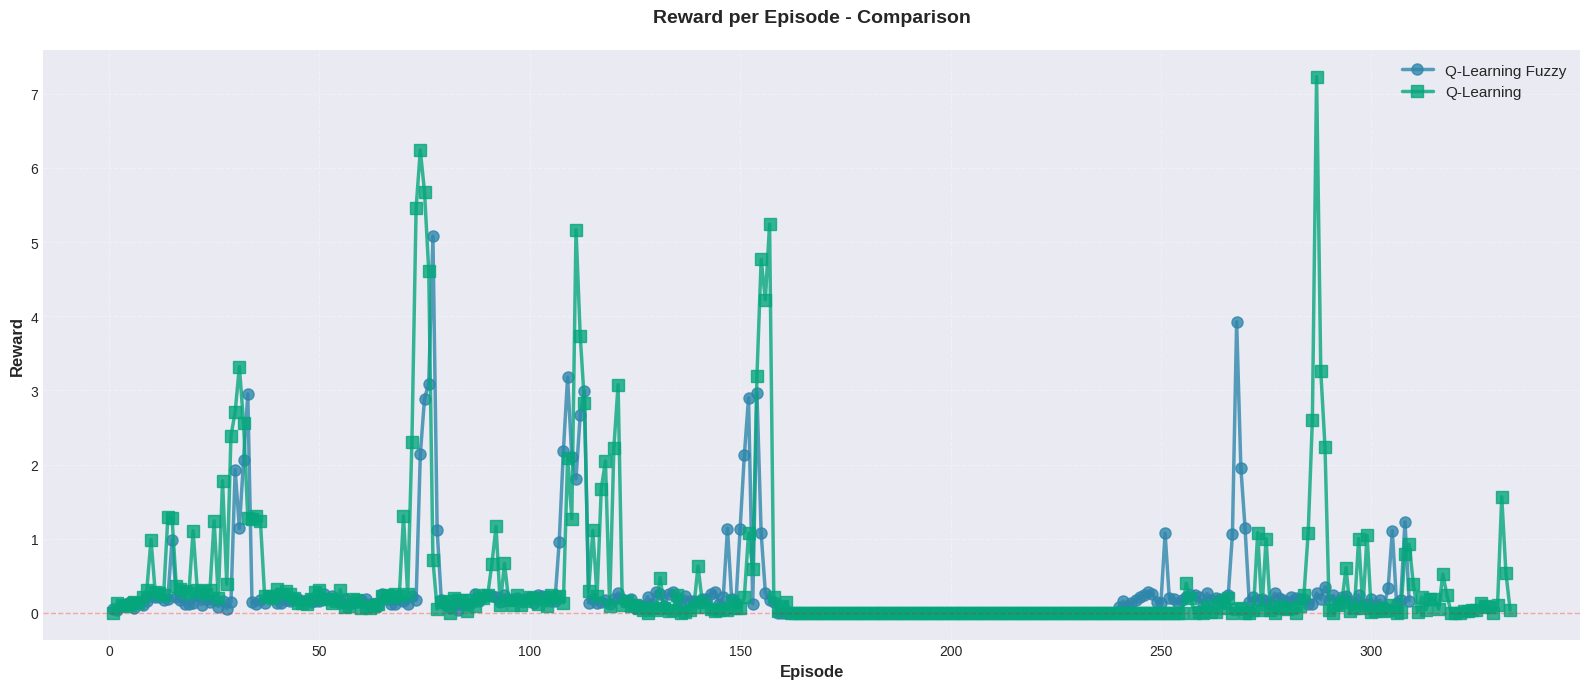


COMPARISON SUMMARY

Q-Learning Fuzzy:
  Episodes: 309
  Mean Reward: 0.309407
  Min Reward: 0.000000 (Episode 159)
  Max Reward: 5.078826 (Episode 77)
  Total Cumulative Reward: 95.606847

Q-Learning:
  Episodes: 333
  Mean Reward: 0.441349
  Min Reward: 0.000000 (Episode 1)
  Max Reward: 7.232667 (Episode 287)
  Total Cumulative Reward: 146.969333



In [27]:
# Visualize reward comparison
if any(data['episodes'] for data in all_data):
    fig, ax = plt.subplots(figsize=(16, 7))
    
    # Define colors for each line
    colors = ['#2E86AB', '#06A77D', '#F18F01', '#D62828', '#A23B72']
    markers = ['o', 's', '^', 'D', 'v']
    
    # Plot each log file's data
    for idx, data in enumerate(all_data):
        if data['episodes']:
            ax.plot(data['episodes'], data['rewards'], 
                   marker=markers[idx % len(markers)], 
                   linewidth=2.5, 
                   markersize=8,
                   color=colors[idx % len(colors)],
                   label=data['label'],
                   alpha=0.8)
    
    ax.set_xlabel('Episode', fontsize=12, fontweight='bold')
    ax.set_ylabel('Reward', fontsize=12, fontweight='bold')
    ax.set_title('Reward per Episode - Comparison', fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    
    # Add zero line for reference
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3, linewidth=1)
    
    plt.tight_layout()
    plt.show()
    
    # Print comparison statistics
    print("\n" + "="*100)
    print("COMPARISON SUMMARY")
    print("="*100)
    
    for data in all_data:
        if data['episodes']:
            print(f"\n{data['label']}:")
            print(f"  Episodes: {len(data['episodes'])}")
            print(f"  Mean Reward: {sum(data['rewards'])/len(data['rewards']):.6f}")
            print(f"  Min Reward: {min(data['rewards']):.6f} (Episode {data['episodes'][data['rewards'].index(min(data['rewards']))]})")
            print(f"  Max Reward: {max(data['rewards']):.6f} (Episode {data['episodes'][data['rewards'].index(max(data['rewards']))]})")
            print(f"  Total Cumulative Reward: {sum(data['rewards']):.6f}")
    
    print("\n" + "="*100)
    
else:
    print("No episode data to visualize.")

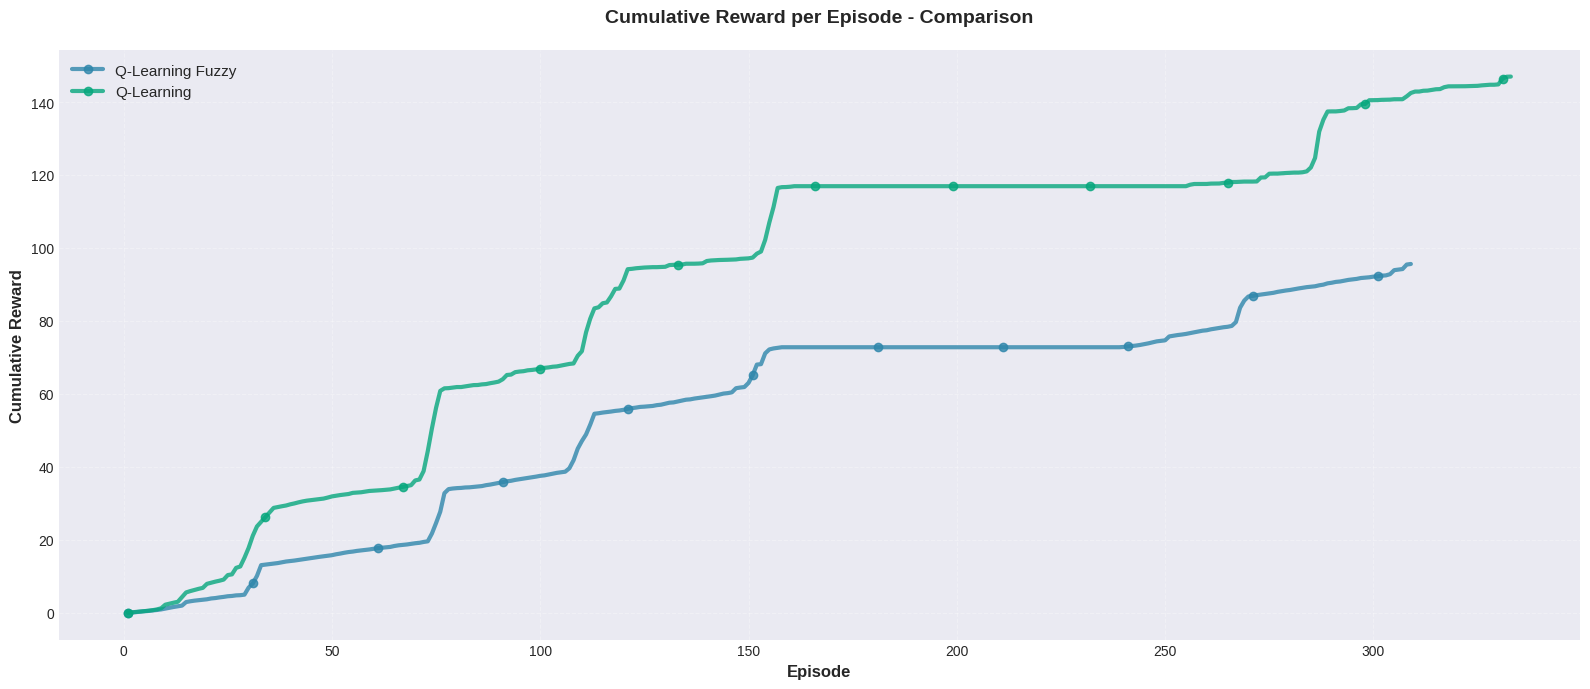

In [28]:
# Optional: Plot cumulative reward comparison
if any(data['episodes'] for data in all_data):
    fig, ax = plt.subplots(figsize=(16, 7))
    
    colors = ['#2E86AB', '#06A77D', '#F18F01', '#D62828', '#A23B72']
    
    for idx, data in enumerate(all_data):
        if data['episodes']:
            # Calculate cumulative reward
            cumulative_rewards = []
            total = 0
            for reward in data['rewards']:
                total += reward
                cumulative_rewards.append(total)
            
            ax.plot(data['episodes'], cumulative_rewards,
                   linewidth=3,
                   color=colors[idx % len(colors)],
                   label=data['label'],
                   alpha=0.8,
                   marker='o',
                   markersize=6,
                   markevery=max(1, len(data['episodes'])//10))
    
    ax.set_xlabel('Episode', fontsize=12, fontweight='bold')
    ax.set_ylabel('Cumulative Reward', fontsize=12, fontweight='bold')
    ax.set_title('Cumulative Reward per Episode - Comparison', fontsize=14, fontweight='bold', pad=20)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    
    plt.tight_layout()
    plt.show()